In [1]:
import numpy as np
import pandas as pd
import rpy2
from rpy2.robjects import r

# import anndata2ri
# anndata2ri.activate()

import matplotlib as mpl
import scanpy as sc

%load_ext rpy2.ipython

In [2]:
%%R
library(devtools)

Loading required package: usethis


In [ ]:
# %%R
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")

# BiocManager::install("SingleCellExperiment")

In [3]:
%%R
devtools::load_all("scDECAF/")

ℹ Loading scDECAF


In [4]:
%%R
load('20240626_d2c_heoca.RData')

In [5]:
%%R
adata

class: SingleCellExperiment 
dim: 2395 806646 
metadata(0):
assays(1): X
rownames(2395): CHEMBL1615779|IOBENGUANE I 131 CHEMBL3989924|LUTETIUM
  DOTATATE LU-177 ... CHEMBL454|BUTALBITAL CHEMBL2105741|TRAMETINIB
  DIMETHYL SULFOXIDE
rowData names(0):
colnames(806646): AAACCTGAGCCACGTC-0 AAACCTGAGTATGACA-0 ...
  TTTGTTGGTTTCAGGA-1-217 TTTGTTGGTTTCCTCC-1-217
colData names(6): publication level_1 ... tissue derive


Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

In [6]:
%%R
reducedDimNames(adata)

[1] "UMAP"


In [7]:
%%R
head(colData(adata))

DataFrame with 6 rows and 6 columns
                                publication    level_1       level_2 Cell_type
                                   <factor>   <factor>      <factor>  <factor>
AAACCTGAGCCACGTC-0 Sampaziotis_Science_2021 epithelial biliary cells       nan
AAACCTGAGTATGACA-0 Sampaziotis_Science_2021 epithelial biliary cells       nan
AAACCTGCACACATGT-0 Sampaziotis_Science_2021 epithelial biliary cells       nan
AAACCTGCACGACGAA-0 Sampaziotis_Science_2021 epithelial biliary cells       nan
AAACCTGCAGCTGGCT-0 Sampaziotis_Science_2021 epithelial biliary cells       nan
AAACCTGCAGTCAGAG-0 Sampaziotis_Science_2021 epithelial biliary cells       nan
                          tissue   derive
                        <factor> <factor>
AAACCTGAGCCACGTC-0 biliarysystem      ASC
AAACCTGAGTATGACA-0 biliarysystem      ASC
AAACCTGCACACATGT-0 biliarysystem      ASC
AAACCTGCACGACGAA-0 biliarysystem      ASC
AAACCTGCAGCTGGCT-0 biliarysystem      ASC
AAACCTGCAGTCAGAG-0 biliarysystem      

In [8]:
%%R
table(colData(adata)$tissue)


biliarysystem     intestine         liver          lung      pancreas 
        36357        353140         63319        225487         90618 
     prostate salivarygland       stomach       thyroid 
         5375         15796         13555          2999 


In [9]:
%%R
table(colData(adata)$derive)


   ASC    FSC    IPS 
262893 185142 358611 


### Lung HEOCA

In [12]:
%%R
adata_hioca = adata[,colData(adata)$tissue == "lung"]
adata_hioca

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
class: SingleCellExperiment 
dim: 2395 225487 
metadata(0):
assays(1): X
rownames(2395): CHEMBL1615779|IOBENGUANE I 131 CHEMBL3989924|LUTETIUM
  DOTATATE LU-177 ... CHEMBL454|BUTALBITAL CHEMBL2105741|TRAMETINIB
  DIMETHYL SULFOXIDE
rowData names(0):
colnames(225487): AAACCCACAAAGCTAA-132 AAACCCACACTGTGTA-132 ...
  TTTGGTTAGTGCAGCA-183 TTTGTTGCACATGAAA-183
colData names(6): publication level_1 ... tissue derive


In [13]:
%%R
tbl = table(adata_hioca$level_2, adata_hioca$derive)
celltypes_lung = rownames(tbl)[rowSums(table(adata_hioca$level_2, adata_hioca$derive) > 0) > 1]

In [14]:
%%R
celltypes_lung

[1] "airway secretory cells"      "alveolar type 1 (AT1) cells"
[3] "alveolar type 2 (AT2) cells" "basal cells"                
[5] "ciliated cells"              "club cells"                 
[7] "goblet cells"                "neuroendocrine cells"       
[9] "stem cells"                 


In [16]:
%%R
load('lung_d2c_scdecaf.RData')

In [17]:
%%R
print(dim(res_lung$m))
print(summary(rowSums(res_lung$m)))

[1] 160   9
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   1.356   2.000   8.000 


In [18]:
%%R
print(summary(colSums(res_lung$m)))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   6.00   19.00   21.00   24.11   32.00   39.00 


In [19]:
%%R
# if (!requireNamespace("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")
# BiocManager::install("ComplexHeatmap")

library(ComplexHeatmap)

Loading required package: grid
ComplexHeatmap version 2.10.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite:
Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
  genomic data. Bioinformatics 2016.

The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))



In [20]:
%%R
head(as.character(res_lung$output))

[1] "CHEMBL3989924|LUTETIUM DOTATATE LU-177"
[2] "CHEMBL1200689|NITRIC OXIDE"            
[3] "CHEMBL1518|PROPYLTHIOURACIL"           
[4] "CHEMBL1453317|DIETHYLTOLUAMIDE"        
[5] "CHEMBL1201568|PEGFILGRASTIM"           
[6] "CHEMBL4594230|LIPEGFILGRASTIM"         


In [21]:
%%R
# create pseudo-bulks per celltype 
lung <- adata[, (adata$tissue %in% "lung") & (adata$level_2 %in% celltypes_lung)]


In [22]:
%%R


make_pb <- function(x,y){
    
    x_scale = t(scale(t(assay(x, 'X')))) # scale each drug
    data <- sapply(y, FUN = function(z) {
        
        matrixStats::rowMedians(x_scale[, colData(x)[,'level_2']==z])
                   }
                  )
    return(data)
                   }

x_lung <- make_pb(lung, celltypes_lung)


In [23]:
%%R
colnames(x_lung) = paste0(colnames(x_lung), "_lung")


In [24]:
%%R
gs <- rownames(res_lung$m)[rowSums(res_lung$m) >=2]

length(gs)

[1] 44


### Multicellular

In [25]:
%%R

require(plyr) # requires plyr for rbind.fill()
cbind.fill <- function(...) {                                                                                                                                                       
  transposed <- lapply(list(...),t)    
  transposed_dataframe <- lapply(transposed, as.data.frame)
  data= data.frame(t(rbind.fill(transposed_dataframe)))
  colnames(data) = unlist(lapply(list(...),colnames))


  return(data)                                                                                                                          
} 



x_df <- x_lung[as.character(rownames(res_lung$m)[rowSums(res_lung$m) >=2]),]

Loading required package: plyr

Attaching package: ‘plyr’

The following object is masked from ‘package:IRanges’:

    desc

The following object is masked from ‘package:S4Vectors’:

    rename

The following object is masked from ‘package:matrixStats’:

    count



In [26]:
%%R
dim(x_df)

[1] 44  9


In [27]:
%%R
x_df[is.na(x_df)] <- 0

In [28]:
%%R
rownames(x_df)

 [1] "CHEMBL1201564|INTERFERON GAMMA-1B"        
 [2] "CHEMBL110458|MIGALASTAT"                  
 [3] "CHEMBL1161|MOMETASONE FUROATE"            
 [4] "CHEMBL1094|FELBAMATE"                     
 [5] "CHEMBL350221|OXITRIPTAN"                  
 [6] "CHEMBL436|TOLRESTAT"                      
 [7] "CHEMBL924|ZOLEDRONIC ACID"                
 [8] "CHEMBL41286|DIACEREIN"                    
 [9] "CHEMBL1070|NABUMETONE"                    
[10] "CHEMBL1201304|INDOCYANINE GREEN"          
[11] "CHEMBL1465|PHENPROCOUMON"                 
[12] "CHEMBL397420|ACENOCOUMAROL"               
[13] "CHEMBL3833307|SATRALIZUMAB"               
[14] "CHEMBL160|CYCLOSPORINE"                   
[15] "CHEMBL1201607|NATALIZUMAB"                
[16] "CHEMBL24072|PRENYLAMINE"                  
[17] "CHEMBL3545057|ACETYLDIGITOXIN"            
[18] "CHEMBL2103738|LITHIUM CITRATE"            
[19] "CHEMBL1200826|LITHIUM CARBONATE"          
[20] "CHEMBL1336|SORAFENIB"                     
[21] "CHEMBL288441|B

In [29]:
%%R
library(RColorBrewer)
bluecols <- brewer.pal(11, 'RdBu')
newcol <- colorRampPalette(rev(bluecols))
ncols <- 256


col = gplots::colorpanel(256, "blue2","white","red2")

In [30]:
%%R
chembl_ids <- gsub('(CHEMBL[0-9]+)\\|(.*)','\\1',rownames(x_df))
length(chembl_ids)

[1] 44


In [31]:
%%R
mdata <- read.delim('ATC_classification_chembl_43.tsv')

In [32]:
%%R

classes <- mdata[match(chembl_ids, mdata$`Parent.Molecule.ChEMBL.ID`)  , c('Parent.Molecule.ChEMBL.ID','Level.1.ATC.Codes')]

In [33]:
%%R
dim(classes)

[1] 44  2


In [34]:
%%R
colnames(classes)[2] = 'level1_ATC'

In [35]:
%%R
classes$level1_ATC[is.na(classes$level1_ATC)] <- 'unknown'
classes$level1_ATC[classes$level1_ATC == ""] <- 'unknown'

In [36]:
%%R
atc_labels = classes$level1_ATC
names(atc_labels) = rownames(x_df)
row_ha = rowAnnotation('Drug category' = atc_labels)

In [37]:
%%R
atc_labels

                                                            CHEMBL1201564|INTERFERON GAMMA-1B 
                                             "L - ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS" 
                                                                      CHEMBL110458|MIGALASTAT 
                                                        "A - ALIMENTARY TRACT AND METABOLISM" 
                                                                CHEMBL1161|MOMETASONE FUROATE 
"D - DERMATOLOGICALS | D - DERMATOLOGICALS | R - RESPIRATORY SYSTEM | R - RESPIRATORY SYSTEM" 
                                                                         CHEMBL1094|FELBAMATE 
                                                                         "N - NERVOUS SYSTEM" 
                                                                      CHEMBL350221|OXITRIPTAN 
                                                                                    "unknown" 
                                                  

In [38]:
%%R
row_ha

A HeatmapAnnotation object with 1 annotation
  name: heatmap_annotation_0 
  position: row 
  items: 44 
  width: 5mm 
  height: 1npc 
  this object is subsetable
  27.7758333333333mm extension on the bottom 

          name annotation_type color_mapping width
 Drug category discrete vector        random   5mm


In [39]:
%%R
save(x_df, atc_labels, file = 'data_lung_complexheatmap_ismb2025.RData')

In [40]:
%%R
as.factor(gsub("(.*)_(.*)","\\2", colnames(x_df)))

[1] lung lung lung lung lung lung lung lung lung
Levels: lung


In addition: Warning message:
The input is a data frame, convert it to a matrix. 


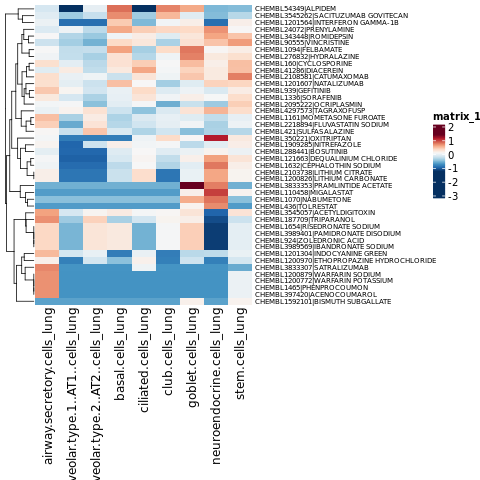

In [41]:
%%R
# REVISIT FILTER BY GLOBAL EXPRESSION STEP, for example based on the weights from the model
group = as.factor(gsub("(.*)_(.*)","\\2", colnames(x_df)))
hm1 = Heatmap(data.frame(x_df)[,group == 'lung'], col = newcol(ncols) ,
              row_names_gp = gpar(fontsize = 7), cluster_columns=FALSE, 
              heatmap_legend_param = list(at = seq(-3,2,1))) 


hm1 